In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/saraalmazroa/-IT326-DataMining-Project-/main/Dataset/german_credit_data-3.csv"
df = pd.read_csv(url)

# Phase 2

# 1-Data Analysis

## Five Number Summary, Boxplots & Outlier Detection

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1) Five Number Summary
numeric_cols = ['Age', 'Job', 'Credit amount', 'Duration']
print("Five Number Summary:")
df[numeric_cols].describe()

Five Number Summary:


,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


# Statistical Summary of the Numeric Attributes

Age: Values span from 19 to 75 years, clustering mainly around 27–42 (median ≈ 33, mean ≈ 35.5). A standard deviation of roughly 11 points to a moderate spread, with the applicant pool skewing toward middle age.

Job: Although coded numerically (0–3), this attribute actually represents categories of job type rather than a true numeric quantity. Given this, a bar chart is a more suitable way to visualize it than the boxplot used for the others.

Credit amount: Loan values range widely, from 250 up to 18,424, with the bulk falling between roughly 1,360 and 3,970 (median ≈ 2,320, mean ≈ 3,271). The large standard deviation (~2,820) reflects this variability, driven by a mix of modest and very large loans.

Duration: Repayment periods run from 4 to 72 months, centered around a median of 18 and a mean near 21. Most loans fall in the 12–24 month range, though a subset extends well beyond that.

*Note: Job is excluded from the outlier analysis, since it is a categorical variable represented with numeric codes rather than a genuinely continuous attribute.*

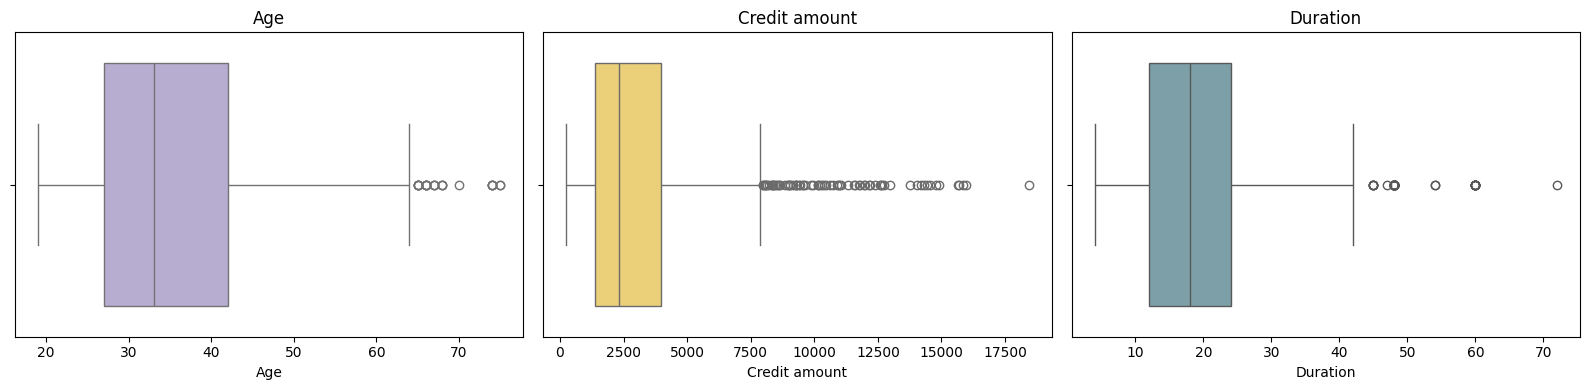

In [ ]:
numeric_colums = ['Age', 'Credit amount', 'Duration']
colors = ['#B4A7D6', '#FFD966', '#76A5AF']
plt.figure(figsize=(16,4))
for i, col in enumerate(numeric_colums, 1):
  plt.subplot(1, 3, i)
  sns.boxplot(x=df[col], color=colors[i-1])
  plt.title(f'{col}')

plt.tight_layout()
plt.show()

#Age Boxplot
Most applicants are between 27–42 years old (median ≈ 33), with 23 outliers above 64.5. The moderate spread suggests normalization may help later, especially for distance-based algorithms.

# Credit Amount Boxplot
Strongly right-skewed — most loans are under ~4,000, but 72 outliers reach up to 18,424. This indicates the need for transformation (e.g., log) to prevent large values from dominating the analysis.

# *Duration Boxplot*
Similar right skew: most durations are 12–24 months, but 70 outliers extend to 72 months. This also points to needing normalization/transformation.

# Outlier Analysis Summary
Age: 2.3% outliers — minimal impact.

Credit amount: 7.2% outliers — consistent with its right-skewed distribution.

Duration: 7% outliers — also right-skewed.
All percentages are under 10%, so records will be kept and handled later via normalization/transformation rather than removed.

In [3]:
## Missing Value Analysis

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/saraalmazroa/-IT326-DataMining-Project-/main/Dataset/Raw_dataset.csv")
df.isnull().sum()

,0
laufkont,0
laufzeit,0
moral,0
verw,0
hoehe,0
sparkont,0
beszeit,0
rate,0
famges,0
buerge,0


In [10]:
missing_analysis = pd.DataFrame({
    'Missing Value' : df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df)) * 100 })

missing_analysis

,Missing Value,Percentage
laufkont,0,0.0
laufzeit,0,0.0
moral,0,0.0
verw,0,0.0
hoehe,0,0.0
sparkont,0,0.0
beszeit,0,0.0
rate,0,0.0
famges,0,0.0
buerge,0,0.0


## Missing Value Analysis:
The dataset contains 1000 records and 21 attributes. The analysis shows that there are no missing values in any attribute.Therefore, no missing value teatment is required for this dataset.

In [11]:
df['kredit'].value_counts()

,count
kredit,
1,700
0,300


In [12]:
df['kredit'].value_counts(normalize=True)*100

,proportion
kredit,
1,70.0
0,30.0


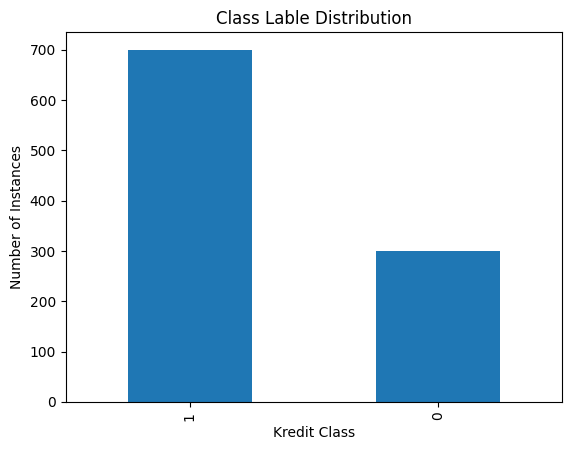

In [14]:
df['kredit'].value_counts().plot(kind='bar')

plt.title('Class Lable Distribution')
plt.xlabel('Kredit Class')
plt.ylabel('Number of Instances')
plt.show()

## Class Lable Distribution:
The class lable is kredit.Class 1 contains 700 instance (70%), while
Class 0 contains 300 instances (30%). This shows that the two classes are not equally distributed, whith Class 1 representing the larger portion of the dataset.

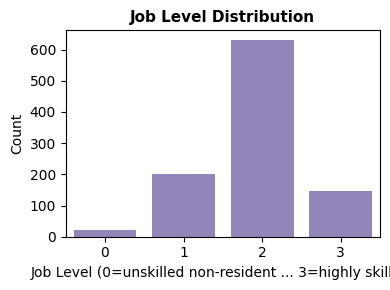

In [ ]:
# 4) Job Distribution (Bar Chart) - Categorical Attribute
plt.figure(figsize=(4, 3))
sns.countplot(x=df['Job'], color='#8E7CC3')
plt.title('Job Level Distribution', fontsize=11, fontweight='bold')
plt.xlabel('Job Level (0=unskilled non-resident ... 3=highly skilled)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Most applicants fall into category 2, with far fewer in 0, 1, and 3. This confirms Job is categorical, not continuous — it may need encoding later, and explains why IQR gave meaningless results for it.

# 2-Data Processing

We saved a copy of our dataset before the data preprocessing stage:

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/saraalmazroa/-IT326-DataMining-Project-/main/Dataset/german_credit_data-3.csv"
df = pd.read_csv(url)

df_rawdata = df.copy()
df_rawdata.describe(include='all')

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,1000.000000,1000.000000,1000,1000.000000,1000,817,606,1000.000000,1000.000000,1000,1000
unique,NaN,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,NaN,male,NaN,own,little,little,NaN,NaN,car,good
freq,NaN,NaN,690,NaN,713,603,274,NaN,NaN,337,700
mean,499.500000,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN,NaN
std,288.819436,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN,NaN
min,0.000000,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN,NaN
25%,249.750000,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN,NaN
50%,499.500000,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN,NaN
75%,749.250000,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN,NaN


# **Noise removeal**

**-Missing Values Handling:**

During this phase, our primary objective was to identify and resolve incomplete data within the dataset, as unaddressed missing values can negatively impact model accuracy and introduce bias. After pinpointing the specific features with missing entries, we applied a mode-based imputation strategy for the categorical variables, replacing the empty cells with the most common category. We opted for this technique over row deletion to prevent valuable information loss and to maintain the original data distribution. Furthermore, using the mode is the standard and most logical approach for categorical data, given that numerical measures like mean and median cannot be applied.


Missing Values Detection

In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

df = df.replace(['NA','na','NaN','NULL','None',''], np.nan)

missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
mv_report = pd.DataFrame({"missing_count": missing_count, "missing_%": missing_pct}).sort_values("missing_count", ascending=False)
display(mv_report)

raw_snapshot = df.head(5).copy()

,missing_count,missing_%
Checking account,394,39.4
Saving accounts,183,18.3
Unnamed: 0,0,0.0
Sex,0,0.0
Age,0,0.0
Housing,0,0.0
Job,0,0.0
Credit amount,0,0.0
Duration,0,0.0
Purpose,0,0.0


To maintain consistency in processing missing data, we first converted various placeholder texts (such as "NA" or "None") into standard NaN formats. Following this, we computed both the total frequency and the proportion of missing entries across all features. This assessment was a crucial preparatory step to pinpoint exactly which variables needed to be addressed during the upcoming imputation phase.

Missing Values Imputation

In [ ]:
from sklearn.impute import SimpleImputer
cat_missing_cols = ['Saving accounts', 'Checking account']
freq_imputer = SimpleImputer(strategy='most_frequent')

df[cat_missing_cols] = freq_imputer.fit_transform(df[cat_missing_cols])

display(df[cat_missing_cols].isnull().sum())

,0
Saving accounts,0
Checking account,0


To address the missing entries in our categorical variables, we applied mode imputation, filling the gaps with the most common category found in each respective feature. This technique allows us to retain important rows and keep the original data patterns intact. Consequently, the 'Saving accounts' and 'Checking account' attributes were successfully filled, leaving zero missing values.

Missing Values Snapshot

In [ ]:
after_impute_snapshot = df.head(5).copy()

print("RAW snapshot (first 5 rows):")
display(raw_snapshot)

print("AFTER Missing-Value Handling snapshot (first 5 rows):")
display(after_impute_snapshot)

RAW snapshot (first 5 rows):


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


AFTER Missing-Value Handling snapshot (first 5 rows):


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,little,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,little,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


The tables below present the initial five records of the dataset, contrasting the data state prior to and following the imputation process. This visual evidence confirms that all empty cells within the 'Saving accounts' and 'Checking account' features were effectively resolved via mode substitution.

**-Outliers Handling:**

In the context of this dataset, it is incorrect to assume that outliers are simply data errors, as they often contain valuable predictive insights. For instance, an unusually high credit amount could strongly indicate a high-risk loan. Therefore, outright deletion of these records is not a viable option. Instead, we chose to reduce the range of values so that we could reduce their impact without losing them completely.


In [ ]:
for column in numeric_colums:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - (1.5 * IQR)
    upper_limit = Q3 + (1.5 * IQR)

    df[column] = np.where(df[column] < lower_limit, lower_limit, df[column])
    df[column] = np.where(df[column] > upper_limit, upper_limit, df[column])

In [ ]:
print ("handled outliers by bounding them aka IQR capping")
display(df[numeric_colums].describe())

handled outliers by bounding them aka IQR capping


,Age,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000
mean,35.453500,3051.101000,20.307000
std,11.106324,2187.140403,10.615151
min,19.000000,250.000000,4.000000
25%,27.000000,1365.500000,12.000000
50%,33.000000,2319.500000,18.000000
75%,42.000000,3972.250000,24.000000
max,64.500000,7882.375000,42.000000


Therefore, we adjusted the extreme values to the closest acceptable limits using the Interquartile Range (IQR) technique. This strategy allowed us to preserve the entire dataset while successfully constraining the extreme data points and mitigating their overall impact.


## Variable Transformation

Variable transformation was applied to the 'Credit amount' attribute of the German Credit dataset.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew
url = "https://raw.githubusercontent.com/saraalmazroa/-IT326-DataMining-Project-/main/Dataset/german_credit_data-3.csv"
df = pd.read_csv(url)
df.head() #To display the first 5 rows

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


###Variable Selection
The Credit amount attribute was chosen for transformation because its values are highly right-skewed. This means that most credit amounts are relatively small, while a few values are much larger. A logarithmic transformation was applied to make the distribution more balanced and reduce the effect of these very large credit amounts.

In [ ]:
original_skewness = skew(df["Credit amount"])

print("Skewness before transformation:", original_skewness)
print("Minimum:", df["Credit amount"].min())
print("Maximum:", df["Credit amount"].max())

Skewness before transformation: 1.946702018941924
Minimum: 250
Maximum: 18424


### Logarithmic Transformation

Logarithmic transformation was applied to reduce the effect of very large credit amounts.

The following formula was applied:
$$
X_{new} = \log(1 + X)
$$

The value 1 is added to make sure the formula can also work when the credit amount is zero.

The transformed values were saved as a new attribute called Credit_amount_log. The original Credit amount attribute was kept as well so that the two versions could be compared.


In [ ]:
df["Credit_amount_log"] = np.log1p(df["Credit amount"])
df[["Credit amount", "Credit_amount_log"]].head(10)

,Credit amount,Credit_amount_log
0,1169,7.064759
1,5951,8.691483
2,2096,7.648263
3,7882,8.972464
4,4870,8.491055
5,9055,9.111183
6,2835,7.950150
7,6948,8.846353
8,3059,8.026170
9,5234,8.563122


In [ ]:
transformed_skewness = skew(df["Credit_amount_log"])

print("Skewness before transformation:", original_skewness)
print("Skewness after transformation:", transformed_skewness)

Skewness before transformation: 1.946702018941924
Skewness after transformation: 0.1301108846710947


###Visual Representation Of  Transformation

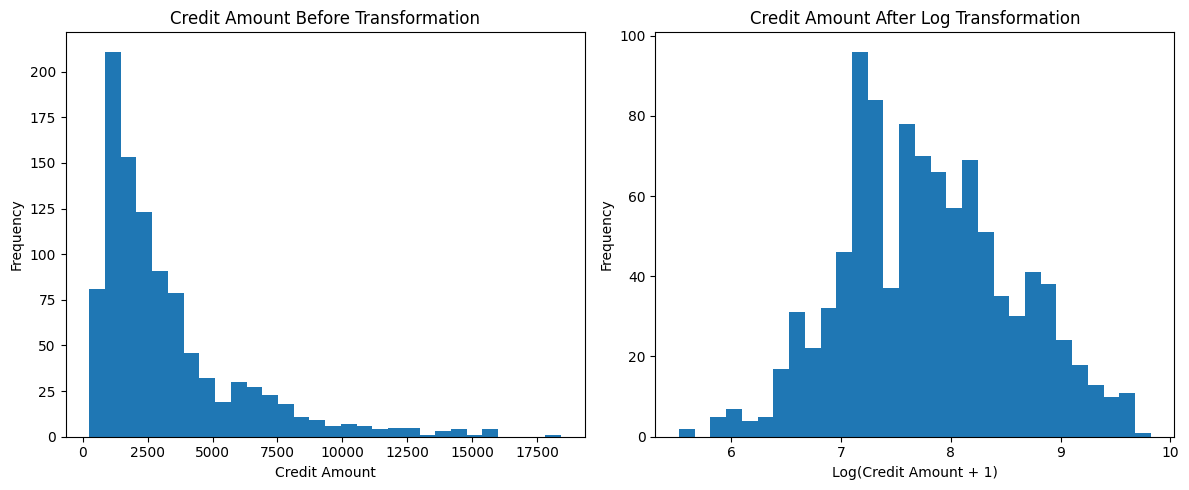

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df["Credit amount"], bins=30)
axes[0].set_title("Credit Amount Before Transformation")
axes[0].set_xlabel("Credit Amount")
axes[0].set_ylabel("Frequency")
axes[1].hist(df["Credit_amount_log"], bins=30)
axes[1].set_title("Credit Amount After Log Transformation")
axes[1].set_xlabel("Log(Credit Amount + 1)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Variable Transformation: The Credit amount attribute was selected for variable transformation because it showed a strong right-skewed distribution, with a skewness value of 1.947 and values ranging from 250 to 18,424. A logarithmic transformation using log(1 + x) was applied.

After applying the logarithmic transformation, the skewness decreased to approximately 0.130, indicating a distribution that is closer to symmetry.

The transformation reduced the relative effect of larger credit amounts while maintaining the ordering of the observations. Overall, the transformed attribute provides a more symmetric distribution for subsequent data analysis and modeling.



## **Normalization** (Min-Max Scaling)

**Goal:** Bring all numeric attributes to the same scale [0, 1] so that no attribute
dominates the others because of its larger range.

**Why:** The numeric attributes are measured on very different scales:
- Age: about 19 to 75
- Duration (months): about 4 to 72
- Credit amount: about 250 to 18,000

Because Credit amount has much bigger numbers, it can overpower the other attributes
when the data is analyzed. Normalization puts all attributes on the same scale
(0 to 1) so they are treated fairly.

**Why Min-Max scaling:**
- Age, Duration and Credit amount have very different ranges.
- Credit amount has much larger numbers, so it could dominate the analysis.
- Min-Max scaling rescales each attribute to 0–1, so all are treated equally.
- It is simple and keeps the original pattern of the data.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

columns_to_normalize = ['Age', 'Credit amount', 'Duration']

print("Before Min-Max Normalization:")
print(df[columns_to_normalize].head())

# Apply Min-Max scaling
scaler = MinMaxScaler()
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

print("\nAfter Min-Max Normalization:")
print(df[columns_to_normalize].head())

# Check that the range is now 0 to 1
print("\nMin and Max after normalization:")
print(df[columns_to_normalize].agg(['min', 'max']))

Before Min-Max Normalization:
   Age  Credit amount  Duration
0   67           1169         6
1   22           5951        48
2   49           2096        12
3   45           7882        42
4   53           4870        24

After Min-Max Normalization:
        Age  Credit amount  Duration
0  0.857143       0.050567  0.029412
1  0.053571       0.313690  0.647059
2  0.535714       0.101574  0.117647
3  0.464286       0.419941  0.558824
4  0.607143       0.254209  0.294118

Min and Max after normalization:
     Age  Credit amount  Duration
min  0.0            0.0       0.0
max  1.0            1.0       1.0


**Result:** After normalization, Age, Credit amount and Duration all range from 0 to 1.

**How it improved the dataset:**
- All numeric attributes are on the same scale.
- No attribute dominates just because it has bigger numbers.
- The dataset is ready for data mining algorithms that are sensitive to scale.